EDA


Split
Test     14518
Train    16108
Name: Count, dtype: int64


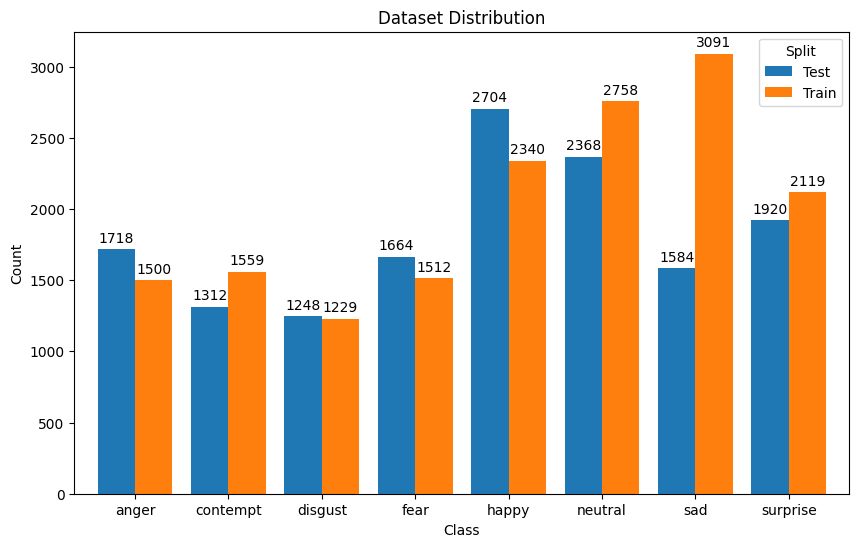

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def get_distribution(root_path):
    root = Path(root_path)
    data = []
    
    # Quét qua các thư mục con cấp 1 (Train, Val, Test)
    for split_dir in root.iterdir():
        if split_dir.is_dir():
            # Quét qua các thư mục lớp (anger, happy...)
            for class_dir in split_dir.iterdir():
                if class_dir.is_dir():
                    count = len(list(class_dir.glob('*')))
                    data.append({
                        'Split': split_dir.name,
                        'Class': class_dir.name,
                        'Count': count
                    })
    return pd.DataFrame(data)

df = get_distribution('dataset')


def plot_data_distribution(df):
  plot_df = df.pivot(index = 'Class', columns = 'Split', values = 'Count')
  ax = plot_df.plot(kind = 'bar',figsize = (10, 6), width = 0.8) 
  for container in ax.containers:
    ax.bar_label(container, padding = 3)
                  
  plt.title('Dataset Distribution')
  plt.ylabel('Count')
  plt.xticks(rotation = 0)
  plt.show()

total_count = df.groupby('Split')['Count'].sum()
print(total_count)
plot_data_distribution(df)

Clean dataset


In [9]:
import hashlib
from pathlib import Path
from PIL import Image

def clean_dataset(path):
    path = Path(path)
    hash_set = set()
    corrupt_count = 0
    duplicate_count = 0

    for img_path in path.rglob('*.*'):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except:
                img_path.unlink()
                corrupt_count += 1
                continue
            image_hash = hashlib.md5(img_path.read_bytes()).hexdigest()
            if image_hash in hash_set:
                img_path.unlink()
                duplicate_count += 1
            else:
                hash_set.add(image_hash)
    print(f"Removed duplicate: {duplicate_count}, Removed corrupt: {corrupt_count}")
clean_dataset(path)

Removed duplicate: 1844, Removed corrupt: 0


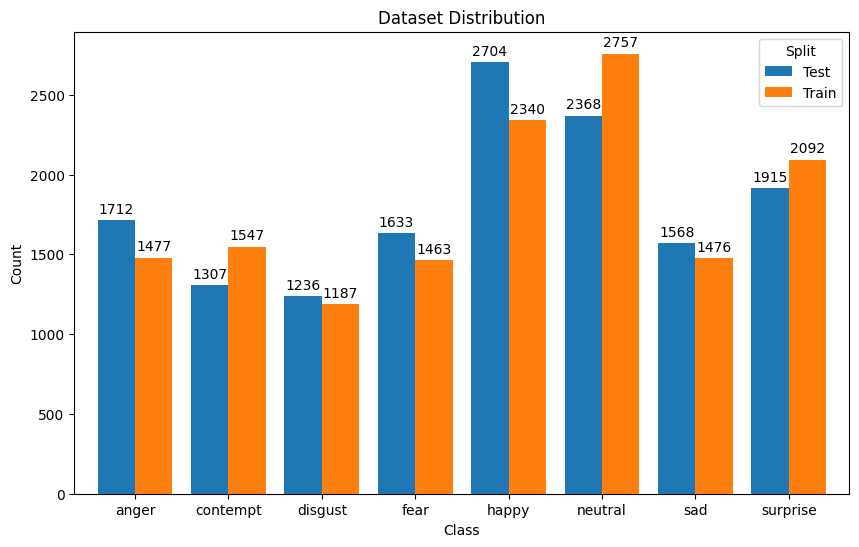

In [10]:
df_after_cleaned = get_distribution('dataset')
plot_data_distribution(df_after_cleaned)

Split Validation set


In [11]:
import random
import shutil
from pathlib import Path

def split_val_set(train_path, val_path, split_ratio=0.2):
    train_path = Path(train_path)
    val_path = Path(val_path)

    for class_dir in train_path.iterdir():
        if class_dir.is_dir():
            # Tạo thư mục lớp tương ứng trong Val
            target_dir = val_path / class_dir.name
            target_dir.mkdir(parents=True, exist_ok=True)
            
            # Lấy danh sách tất cả ảnh trong lớp
            images = [f for f in class_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
            random.seed(36)
            random.shuffle(images) # Xáo trộn ngẫu nhiên
            
            # Tính số lượng ảnh cần chuyển sang Val
            val_size = int(len(images) * split_ratio)
            val_images = images[:val_size]
            
            # Di chuyển file
            for img in val_images:
                shutil.move(str(img), str(target_dir / img.name))
                
    print(f"Complete Validation ({split_ratio*100}%)")

# Thực hiện chia
split_val_set('dataset/Train', 'dataset/Validation', split_ratio=0.2)

Complete Validation (20.0%)


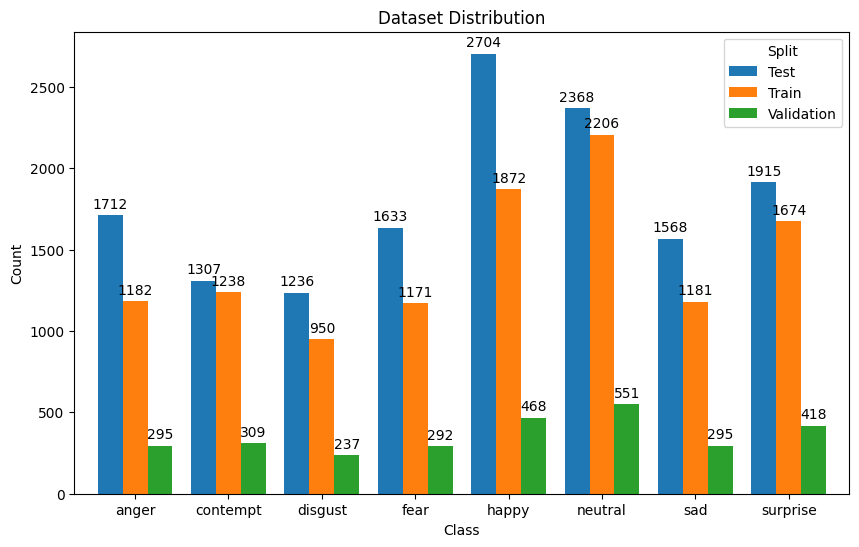

In [12]:
df_after_split_val = get_distribution('dataset')
plot_data_distribution(df_after_split_val)

Augmentation

In [13]:
import hashlib
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

train_path = Path("dataset/Train")
minority_classes = ['disgust', 'contempt', 'fear', 'anger', 'sad', 'surprise', 'happy']
class_count = {d.name: len(list(d.glob('*'))) for d in train_path.iterdir() if d.is_dir()}
target_count = max(class_count.values())

datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    brightness_range = [0.8, 1.2],
    zoom_range = 0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

for cls in minority_classes:
    class_path = train_path / cls
    current_count = class_count[cls]
    needed = target_count - current_count
    if needed <= 0: continue

    print(f'Augmenting {cls}: Needed {needed} images')
    img_paths = list(class_path.glob('*'))
    i = 0
    while i < needed:
        for p in img_paths:
            if i >= needed: break
            
            img = load_img(p)
            x = img_to_array(img)
            x = x.reshape((1,) + x.shape)

            for batch in datagen.flow(x, batch_size=1, save_to_dir=class_path, save_prefix='aug', save_format='jpg'):
                i += 1
                break
print("Data augmentation completed.")

Augmenting disgust: Needed 1256 images
Augmenting contempt: Needed 968 images
Augmenting fear: Needed 1035 images
Augmenting anger: Needed 1024 images
Augmenting sad: Needed 1025 images
Augmenting surprise: Needed 532 images
Augmenting happy: Needed 334 images
Data augmentation completed.


Visualization

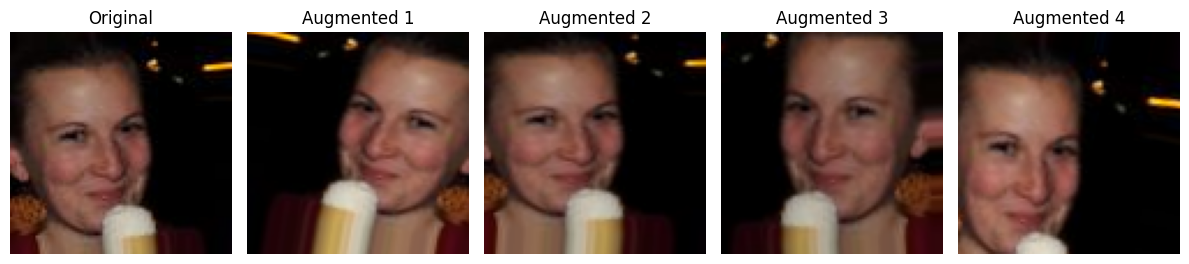

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_augmentation(image_path):
    img = load_img(image_path)
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 5, 1)
    plt.title('Original')
    plt.imshow(img)
    plt.axis('off')

    i = 2
    for batch in datagen.flow(x, batch_size=1):
        plt.subplot(1, 5, i)
        plt.title(f'Augmented {i-1}')
        plt.imshow(batch[0].astype('uint8'))
        plt.axis('off')
        i += 1
        if i > 5: break
    plt.tight_layout()
    plt.show()

sample_image = next((train_path / 'happy').glob('*.jpg'))
visualize_augmentation(sample_image)

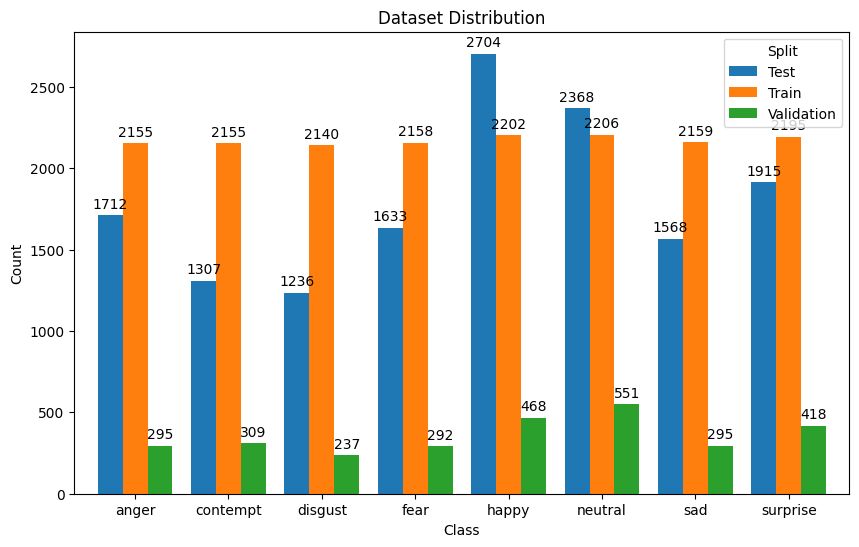

In [16]:
df_completed = get_distribution('dataset')
plot_data_distribution(df_completed)